In [23]:
START_DATE = "2000-01-01"
END_DATE = "2025-12-31"

In [ ]:
from geopy.geocoders import Nominatim
import ee
from dotenv import load_dotenv
import os

In [25]:
load_dotenv()

False

In [26]:
# Autentica com o Google Earth Engine
# Descomente se for a primeira execução
ee.Authenticate()


True

In [27]:
# Inicializa o Earth Engine
ee.Initialize(project=os.environ.get("GOOGLE_EARTH_ENGINE_PROJECT_ID"))

In [28]:
# Geocodifica
geolocator = Nominatim(user_agent="geoapi")
location = geolocator.geocode("Manhuaçu, Minas Gerais, Brazil")
print("location:")
print(location)
print("\n")
point = ee.Geometry.Point([location.longitude, location.latitude])
print("point:")
print(point)

geometry = point.buffer(10000)  # 10 km de raio

# Usa essa geometria no filtro
ndvi_collection = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
    .filterBounds(geometry)
    .filterDate(START_DATE, END_DATE)
    .select("NDVI")
)

location:
Manhuaçu, Região Geográfica Imediata de Manhuaçu, Região Geográfica Intermediária de Juiz de Fora, Minas Gerais, Região Sudeste, Brasil


point:
ee.Geometry({
  "functionInvocationValue": {
    "functionName": "GeometryConstructors.Point",
    "arguments": {
      "coordinates": {
        "constantValue": [
          -42.0340769,
          -20.2574434
        ]
      }
    }
  }
})


In [29]:
# Função para reduzir por média regional e transformar em Feature com data e valor
def image_to_feature(img):
    mean_dict = img.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=geometry, scale=250, maxPixels=1e13
    )
    return ee.Feature(
        None, {"date": img.date().format("YYYY-MM-dd"), "ndvi": mean_dict.get("NDVI")}
    )

In [30]:
# Aplica a função a todas as imagens
ndvi_features = ndvi_collection.map(image_to_feature)

In [31]:
# Coleta os dados em Python
ndvi_list = ndvi_features.getInfo()['features']

In [32]:
import pandas as pd  # Converte para DataFrame


data = [
    {"date": f["properties"]["date"], "ndvi": f["properties"]["ndvi"]}
    for f in ndvi_list
]
df = pd.DataFrame(data)

df["ndvi"] = pd.to_numeric(df["ndvi"], errors="coerce") / 10000  # escala 0–1

df

,date,ndvi
0,2000-02-18,0.705960
1,2000-03-05,0.740228
2,2000-03-21,0.756885
3,2000-04-06,0.767704
4,2000-04-22,0.741535
...,...,...
574,2025-02-02,0.704660
575,2025-02-18,0.723375
576,2025-03-06,0.745835
577,2025-03-22,0.741318


<Axes: xlabel='date'>

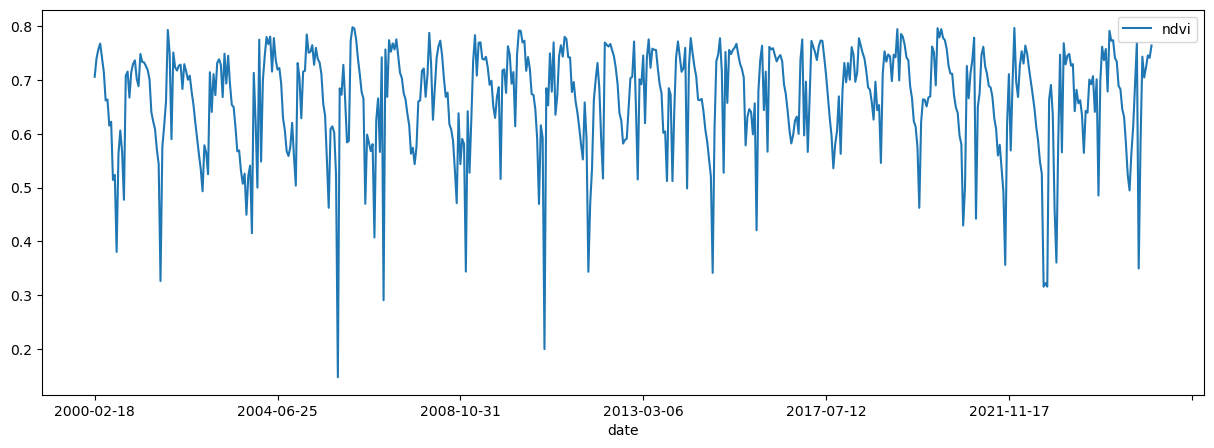

In [33]:
df.plot(x="date", y="ndvi", figsize=(15, 5))

In [34]:
# Exporta como CSV
if not os.path.exists("../data/GOOGLE_EARTH_ENGINE"):
    os.makedirs("../data/GOOGLE_EARTH_ENGINE")
df.to_csv("../data/GOOGLE_EARTH_ENGINE/ndvi_manhuacu.csv", index=False)
print("✅ CSV salvo com sucesso!")

✅ CSV salvo com sucesso!


## Load Images

In [35]:
final_year_dates = pd.date_range(start="2017-12-31", end="2023-12-31", freq="12ME")
final_year_dates

DatetimeIndex(['2017-12-31', '2018-12-31', '2019-12-31', '2020-12-31',
               '2021-12-31', '2022-12-31', '2023-12-31'],
              dtype='datetime64[ns]', freq='12ME')

In [ ]:
from datetime import timedelta
    
import time

delta = timedelta(days=1)

print("Coordenadas da região de exportação:")
print(geometry.bounds().getInfo())  # Verifique a área da geometria

for date in final_year_dates:
    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(geometry)
        .filterDate(
            # (date - delta).strftime("%Y-%m-%d"), (date + delta).strftime("%Y-%m-%d")
            f"{date.year}-01-01", f"{date.year}-12-31"
        )
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    )
    print("\nAno:", date.year)
    print("Número de imagens no ano:", collection.size().getInfo())
    
    print("\nImagens disponíveis:")
    dates = collection.aggregate_array("system:time_start").getInfo()
    from datetime import datetime

    for ts in dates:
        print(datetime.utcfromtimestamp(ts / 1000).strftime("%Y-%m-%d"))

    # image = collection.median().clip(geometry)
    
    # print("Bandas da imagem:")
    # print(image.bandNames().getInfo())  # deve retornar algo como ['B4', 'B3', 'B2']
    
    # if image.bandNames().getInfo() == []:
    #     print(f"Nenhuma imagem disponível para essa data: {date.strftime('%Y-%m-%d')}")
    #     continue
    
    # # Seleciona bandas RGB corrigidas
    # image = image.select(["B4", "B3", "B2"])  # Red, Green, Blue

    # # Aplica escala (dados vêm em inteiro, escala de 0–10000)
    # # image = image.multiply(0.0000275).add(-0.2).clamp(0, 1)  # Correção padrão SR
    
    # description = f"Manhuacu_export_{date.strftime('%Y%m%d')}"
    # file_name = f"Manhuacu_{date.strftime('%Y%m%d')}"

    # rgb_vis = {
    #     'min': 0.0,
    #     'max': 3000,
    #     'bands': ["B4", "B3", "B2"]
    # }

    # # Exporta para Google Drive
    # task = ee.batch.Export.image.toDrive(
    #     image=image.visualize(**rgb_vis),
    #     description=description,
    #     folder="GEE_Manhuacu",
    #     fileNamePrefix=file_name,
    #     region=geometry.bounds().getInfo()["coordinates"],
    #     scale=10,
    #     maxPixels=1e13,
    # )
    # task.start()

    # print(f"Exportando: {file_name}")
    # time.sleep(5)  # Pequena pausa para permitir inicialização

    # # Verifica status da tarefa
    # status = task.status()
    # print(f"Status da tarefa: {status['state']}")
    # if 'error_message' in status:
    #     print("Erro:", status['error_message'])

Coordenadas da região de exportação:
{'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-42.129224910120335, -20.347397457498595], [-41.9386394206861, -20.347397457498595], [-41.9386394206861, -20.16745474048515], [-42.129224910120335, -20.16745474048515], [-42.129224910120335, -20.347397457498595]]]}
Ano: 2017
Número de imagens no ano: 0

Imagens disponíveis:
Ano: 2018
Número de imagens no ano: 1

Imagens disponíveis:
2018-12-15
Ano: 2019
Número de imagens no ano: 35

Imagens disponíveis:
2019-01-09
2019-01-09
2019-01-24
2019-01-29
2019-01-29
2019-02-03
2019-02-03
2019-02-23
2019-03-15
2019-03-15
2019-04-29
2019-05-24
2019-05-24
2019-05-29
2019-06-13
2019-06-28
2019-06-28
2019-07-08
2019-07-08
2019-07-13
2019-07-13
2019-07-28
2019-07-28
2019-08-02
2019-08-02
2019-08-12
2019-08-17
2019-09-01
2019-09-01
2019-09-11
2019-09-21
2019-11-05
2019-11-05
2019-11-10
2019-12-15
Ano: 2020
Número de imagens no ano: 36

Imagens disponíveis:
2020-03-29
2020-04-03
2020-04-28
2020-04-28
2020-05-1